# Exploratory Data Analysis: What Drives Laptop Prices?

Regression and box plots for every feature, a GPU × CPU-core pivot table with a heatmap, and Pearson correlation against price for each column.

*Lab from IBM's **Data Analysis with Python** course (Coursera), documented in my own words.*

**Skills:** regression plots, box plots, pivot tables, heatmaps, Pearson correlation

## Load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

In [4]:
filepath="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

In [5]:
file_name = filepath  # read straight from the URL

In [6]:
df = pd.read_csv(file_name, header=0)

In [10]:
df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


## Visualize individual feature patterns

(0.0, 3974.15)

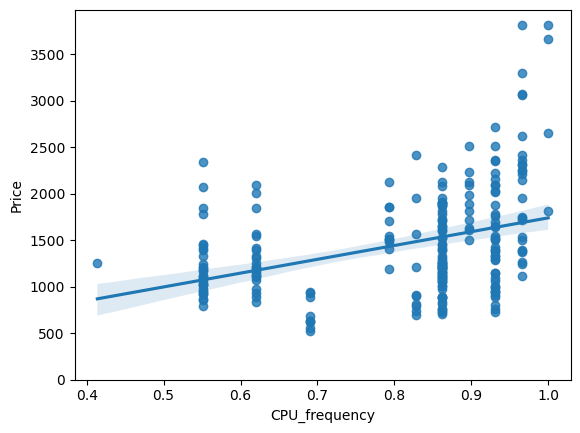

In [12]:
# CPU_frequency plot
sns.regplot(x= 'CPU_frequency', y= 'Price', data=df)
plt.ylim(0,)

(0.0, 3974.15)

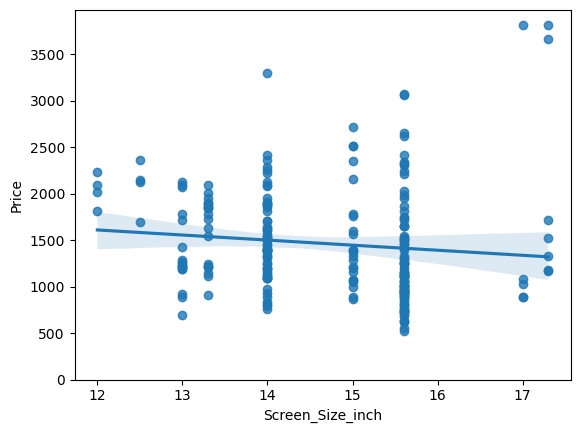

In [13]:
# Screen_Size_inch plot
sns.regplot(x= 'Screen_Size_inch', y= 'Price', data=df)
plt.ylim(0,)

<AxesSubplot:xlabel='Weight_pounds', ylabel='Price'>

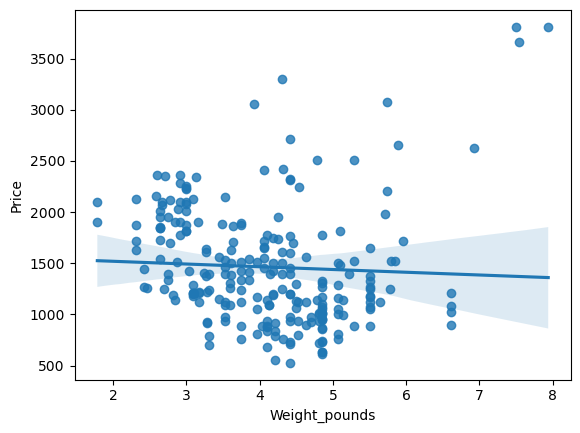

In [14]:
# Weight_pounds plot
sns.regplot(x= 'Weight_pounds', y= 'Price', data=df)
# plt.ylim(0,)

In [21]:
# Correlation values of the three attributes with Price
df[['CPU_frequency', 'Screen_Size_inch', 'Weight_pounds', 'Price']].corr()

# for param in ["CPU_frequency", "Screen_Size_inch","Weight_pounds"]:
#     print(f"Correlation of Price and {param} is {df[[param,"Price"]].corr()}")

,CPU_frequency,Screen_Size_inch,Weight_pounds,Price
CPU_frequency,1.000000,-0.000948,0.066522,0.366666
Screen_Size_inch,-0.000948,1.000000,0.797534,-0.110644
Weight_pounds,0.066522,0.797534,1.000000,-0.050312
Price,0.366666,-0.110644,-0.050312,1.000000


### Categorical features

<AxesSubplot:xlabel='Category', ylabel='Price'>

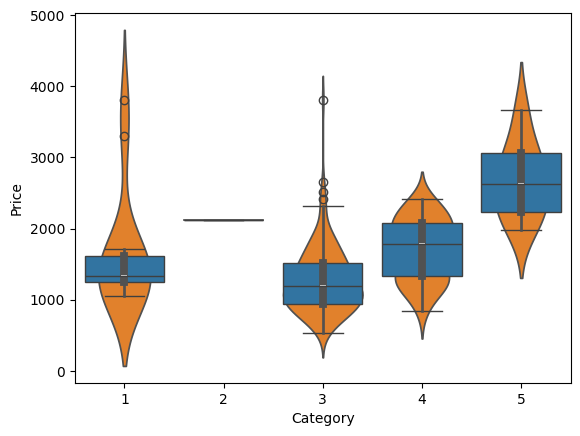

In [43]:
# Category Box plot
sns.boxplot(x= 'Category', y= 'Price', data=df)
sns.violinplot(x= 'Category', y= 'Price', data=df)

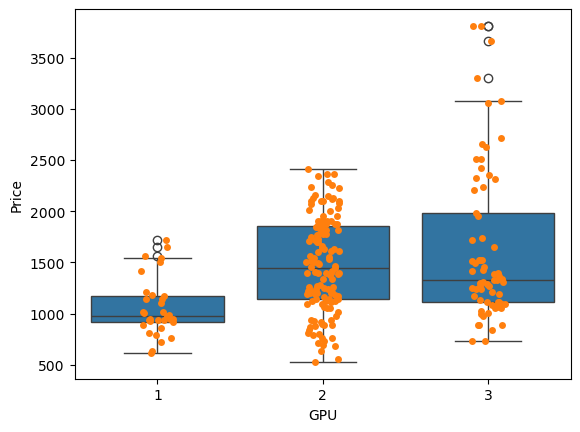

In [29]:
# GPU Box plot
sns.boxplot(x= 'GPU', y= 'Price', data=df)
sns.stripplot(data=df, x='GPU', y='Price')
plt.show()

<AxesSubplot:xlabel='OS', ylabel='Price'>

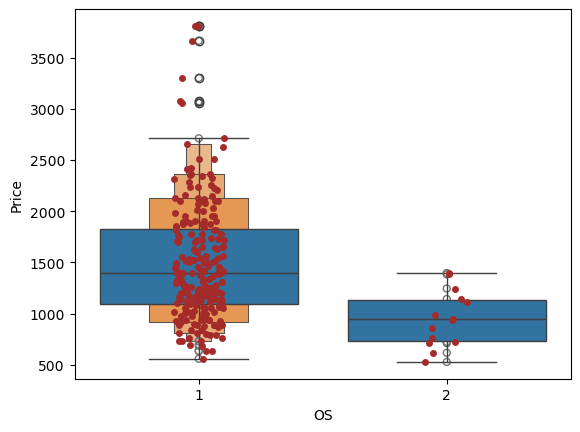

In [49]:
# OS Box plot
sns.boxplot(x= 'OS', y= 'Price', data=df)
sns.boxenplot(data=df, x='OS', y='Price')
sns.stripplot(data=df, x='OS', y='Price', color='brown')

<AxesSubplot:xlabel='CPU_core', ylabel='Price'>

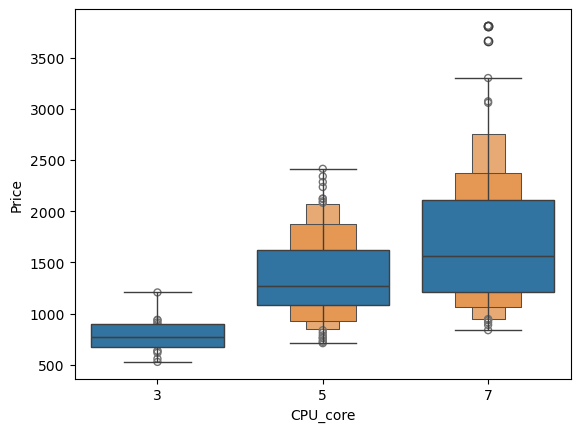

In [51]:
# CPU_core Box plot
sns.boxplot(x= 'CPU_core', y= 'Price', data=df)
sns.boxenplot(x= 'CPU_core', y= 'Price', data=df)

<AxesSubplot:xlabel='RAM_GB', ylabel='Price'>

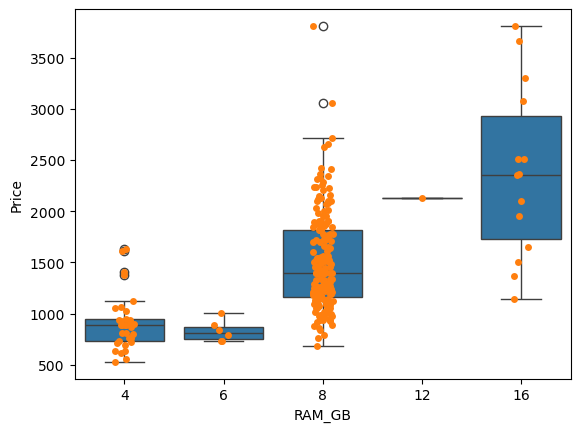

In [55]:
# RAM_GB Box plot
sns.boxplot(x= 'RAM_GB', y= 'Price', data=df)
sns.stripplot(x= 'RAM_GB', y= 'Price', data=df)

<AxesSubplot:xlabel='Storage_GB_SSD', ylabel='Price'>

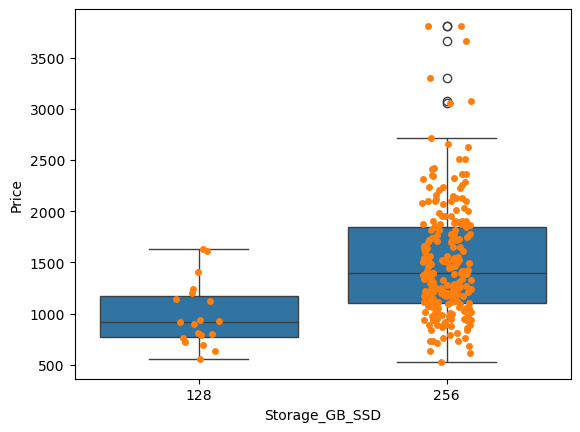

In [57]:
# Storage_GB_SSD Box plot
sns.boxplot(x= 'Storage_GB_SSD', y= 'Price', data=df)
sns.stripplot(x= 'Storage_GB_SSD', y= 'Price', data=df)

## Descriptive Statistical Analysis

In [61]:
df.describe(include='all')

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
count,238,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238,238.000000,238.000000
unique,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN
top,Dell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN
freq,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160,NaN,NaN
mean,NaN,3.205882,2.151261,1.058824,5.630252,14.688655,0.813822,7.882353,245.781513,4.106221,1462.344538,NaN,0.676471,0.323529
std,NaN,0.776533,0.638282,0.235790,1.241787,1.166045,0.141860,2.482603,34.765316,1.078442,574.607699,NaN,0.468809,0.468809
min,NaN,1.000000,1.000000,1.000000,3.000000,12.000000,0.413793,4.000000,128.000000,1.786050,527.000000,NaN,0.000000,0.000000
25%,NaN,3.000000,2.000000,1.000000,5.000000,14.000000,0.689655,8.000000,256.000000,3.246863,1066.500000,NaN,0.000000,0.000000
50%,NaN,3.000000,2.000000,1.000000,5.000000,15.000000,0.862069,8.000000,256.000000,4.106221,1333.000000,NaN,1.000000,0.000000
75%,NaN,4.000000,3.000000,1.000000,7.000000,15.600000,0.931034,8.000000,256.000000,4.851000,1777.000000,NaN,1.000000,1.000000


## GroupBy and Pivot Tables

In [93]:
# Create the group
group1 = df.groupby(['GPU', 'CPU_core']).agg({'Price':'mean'})

In [96]:
# Create the Pivot table
# pd.pivot_table(df, index='GPU', columns=['CPU_core'], values='Price', aggfunc='mean')
group1 = group1.unstack()

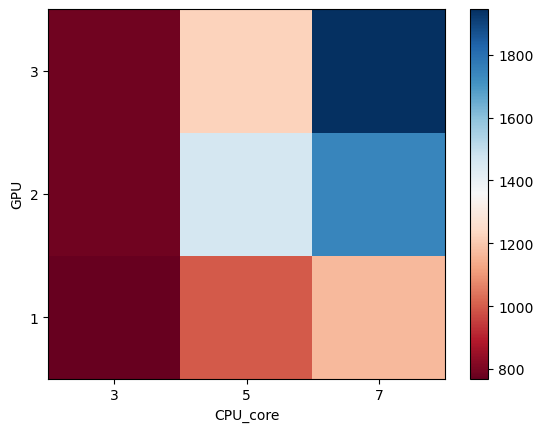

In [97]:
# Create the Plot
# plt.pcolor(group1, cmap='RdBu')
# plt.colorbar()
# plt.show()

fig, ax = plt.subplots()
im = ax.pcolor(group1, cmap='RdBu')

# put the labels in the middle of each square
ax.set_xticks(np.arange(group1.shape[1]) + 0.5)
ax.set_yticks(np.arange(group1.shape[0]) + 0.5)

# label names
ax.set_xticklabels(group1.columns.levels[1])
ax.set_yticklabels(group1.index)

ax.set_xlabel('CPU_core')
ax.set_ylabel('GPU')
fig.colorbar(im)
plt.show()

## Pearson Correlation and p-values

In [116]:
loop = df[['CPU_frequency', 'Screen_Size_inch', 'Weight_pounds', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'GPU', 'OS', 'Category']]
for param in loop:
    coef, p_value = stats.pearsonr(df[param],df['Price'])
    print(f"The Pearson correlation for {param}:\ncoefficient value= {coef}\nP-value= {p_value}\n")

The Pearson correlation for CPU_frequency:
coefficient value= 0.3666655589258861
P-value= 5.50246335071342e-09

The Pearson correlation for Screen_Size_inch:
coefficient value= -0.11064420817118291
P-value= 0.08853397846830661

The Pearson correlation for Weight_pounds:
coefficient value= -0.050312258377515455
P-value= 0.4397693853433894

The Pearson correlation for RAM_GB:
coefficient value= 0.5492972971857849
P-value= 3.6815606288424503e-20

The Pearson correlation for Storage_GB_SSD:
coefficient value= 0.24342075521810297
P-value= 0.00014898923191724168

The Pearson correlation for CPU_core:
coefficient value= 0.45939777733551174
P-value= 7.912950127008979e-14

The Pearson correlation for GPU:
coefficient value= 0.2882981988881427
P-value= 6.166949698364507e-06

The Pearson correlation for OS:
coefficient value= -0.22172980114827356
P-value= 0.0005696642559246817

The Pearson correlation for Category:
coefficient value= 0.286242755812641
P-value= 7.225696235806858e-06



## What I took away

- **Strongest price drivers:** RAM (r = 0.55), CPU cores (0.46), CPU frequency (0.37).
- **Not significant:** screen size (p = 0.09) and weight (p = 0.44).
- The heatmap showed something `corr()` can't: a better GPU only raises price when the CPU is also strong.